<a href="https://colab.research.google.com/github/Alex-ismymind/muhammad-muhajir/blob/main/muhammad_muhajir_praktikum_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten

In [9]:
import os

arial_path = "/content/drive/MyDrive/dataset bab 5/dataset/Arial"
brandish_path = "/content/drive/MyDrive/dataset bab 5/dataset/Brandish"
consolas_path = "/content/drive/MyDrive/dataset bab 5/dataset/Consolas"
didot_path = "/content/drive/MyDrive/dataset bab 5/dataset/Didot"


arial_filenames = os.listdir(arial_path)
brandish_filenames = os.listdir(brandish_path)
consolas_filenames = os.listdir(consolas_path)
didot_filenames = os.listdir(didot_path)

In [10]:
arial_filenames[:5]

['Image_4596.jpg',
 'Image_4592.jpg',
 'Image_4638.jpg',
 'Image_459.jpg',
 'Image_4625.jpg']

In [11]:
def load_image(filenames, path):
    images = []
    for filename in tqdm(filenames):
        image = cv2.imread(path+'/'+filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        images.append(image)
    return images


In [12]:
arial_images = load_image(arial_filenames, arial_path)
brandish_images = load_image(brandish_filenames, brandish_path)
consolas_images = load_image(consolas_filenames, consolas_path)
didot_images = load_image(didot_filenames, didot_path)

100%|██████████| 5000/5000 [28:10<00:00,  2.96it/s]


In [13]:
heights = []
widths = []

for image in arial_images:
    height = image.shape[0]
    width = image.shape[1]
    heights.append(height)
    widths.append(width)

print('max_h: {}, min_h: {}'.format(max(heights), min(heights)))
print('max_w: {}, min_w: {}'.format(max(widths), min(widths)))

max_h: 32, min_h: 32
max_w: 231, min_w: 29


In [14]:

def take_80_pixels(images_list):
    new_images = []
    for image in images_list:
        if image.shape[1] >= 80:
            new_images.append(image[:, :80])
        else:
            pass
    return np.array(new_images)

In [15]:
arial_80 = take_80_pixels(arial_images)
brandish_80 = take_80_pixels(brandish_images)
consolas_80 = take_80_pixels(consolas_images)
didot_80 = take_80_pixels(didot_images)

In [16]:
print(arial_80.shape)
print(brandish_80.shape)
print(consolas_80.shape)
print(didot_80.shape)

(4112, 32, 80)
(4054, 32, 80)
(4731, 32, 80)
(3894, 32, 80)


In [17]:
all_images = np.append(arial_80, brandish_80, axis=0)
all_images = np.append(all_images, consolas_80, axis=0)
all_images = np.append(all_images, didot_80, axis=0)
all_images.shape

(16791, 32, 80)

In [18]:
ll_images = all_images.reshape(all_images.shape[0],
                               all_images.shape[1],
                               all_images.shape[2],
                               1)
all_images.shape

(16791, 32, 80)

In [19]:
labels = [0]*len(arial_80) + \
         [1]*len(brandish_80) + \
         [2]*len(consolas_80) + \
         [3]*len(didot_80)

len(labels)

16791

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(all_images, labels, test_size=0.3, random_state=88)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [21]:
y_train = y_train[:, np.newaxis]
y_test = y_test[:, np.newaxis]

In [22]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)

y_train_encoded = one_hot_encoder.fit_transform(y_train)

In [23]:
print(y_train[:5])
print(y_train_encoded[:5])

[[1]
 [2]
 [2]
 [2]
 [3]]
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [24]:
input_shape = (all_images.shape[1],
               all_images.shape[2],
               1)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,744,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,768,170 (14.37 MB)

 Trainable params: 3,768,170 (14.37 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics=['acc'])

In [28]:
y_test_encoded = one_hot_encoder.transform(y_test)
history = model.fit(X_train, y_train_encoded,
                    epochs=3,
                    validation_data=(X_test, y_test_encoded))

Epoch 1/3
368/368 ━━━━━━━━━━━━━━━━━━━━ 124s 331ms/step - acc: 0.9097 - loss: 4.7085 - val_acc: 0.9877 - val_loss: 0.0506
Epoch 2/3
368/368 ━━━━━━━━━━━━━━━━━━━━ 128s 349ms/step - acc: 0.9860 - loss: 0.0431 - val_acc: 0.9923 - val_loss: 0.0321
Epoch 3/3
368/368 ━━━━━━━━━━━━━━━━━━━━ 131s 319ms/step - acc: 0.9378 - loss: 0.2021 - val_acc: 0.9911 - val_loss: 0.0379


In [ ]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
predictions

In [ ]:
y_test = y_test.reshape(y_test.shape[0])
y_test

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)
label_names = ['arial', 'brandish', 'consolas', 'didot']

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=label_names,
            yticklabels=label_names,
            cmap=plt.cm.Blues)

In [ ]:
misses = []
for i in range(len(predictions)):
    if y_test[i] != predictions[i]:
        misses.append(i)

print(misses)

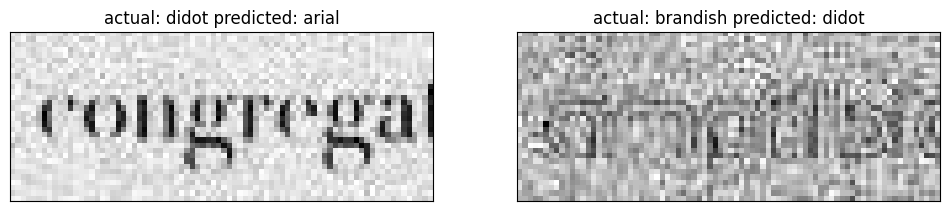

In [33]:
fig, axes = plt.subplots(ncols=2, sharex=False, figsize=(12, 3))

for i in range(2):
    miss = misses[i]
    axes[i].set_title('actual: {} predicted: {}'.format(
        label_names[y_test[miss]],
        label_names[predictions[miss]]))
    axes[i].imshow(X_test[miss], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)

plt.show()
